<a href="https://colab.research.google.com/github/devgerlancsilva/GoogleBuildwithAI/blob/main/DemoBwAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2025 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# API Gemini: Introdução aos modelos Gemini

O novo **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** fornece uma interface unificada para [Modelos Gemini](https://ai.google.dev/gemini-api/docs/models) através da [API do desenvolvedor Gemini](https://ai.google.dev/gemini-api/docs) e a API Gemini no [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview). Com algumas exceções, o código executado em uma plataforma será executado em ambas. Este notebook usa a API do desenvolvedor.

Este Colab irá guiá-lo através de:

* [Instalação e configuração](Get_started.ipynb#scrollTo=Mfk6YY3G5kqp) o SDK do Google GenAI
* [Texto](Get_started.ipynb#scrollTo=6TYNPrNvQ8ue) e [multimodal](#scrollTo=yww-vrxmRiIy) prompting
* Contagem de [tokens](Get_started.ipynb#scrollTo=_9B8pb7tv_Cx)

## Configuração

### Instalação do SDK

In [ ]:
%pip install -U -q 'google-genai>=1.16.0'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.0/200.0 kB 5.0 MB/s eta 0:00:00


### Configure sua chave de API

Para executar a célula a seguir, sua chave de API deve ser armazenada em um Colab Secret chamado `GOOGLE_API_KEY`. Se você ainda não tem uma chave de API ou não tem certeza de como criar um Colab Secret, consulte [Autenticação](../quickstarts/Authentication.ipynb) por exemplo.

In [ ]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

### Inicializar cliente SDK

Com o novo SDK, agora você só precisa inicializar um cliente com sua chave de API (ou OAuth, se estiver usando [Vertex AI](https://cloud.google.com/vertex-ai)). O modelo agora é definido em cada chamada.

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

### Escolha um modelo

Selecione o modelo que deseja usar neste guia. Você pode selecionar um da lista ou inserir o nome do modelo manualmente. Lembre-se de que alguns modelos, como o 2.5, são modelos de pensamento e, portanto, levam um pouco mais de tempo para responder. Para mais detalhes, consulte o [thinking notebook](./Get_started_thinking.ipynb) para saber como desativar a função pensamento.

In [ ]:
MODEL_ID = "gemini-2.5-flash-preview-05-20" # @param ["gemini-2.5-flash-preview-05-20", "gemini-2.5-pro-preview-05-06", "gemini-2.0-flash-lite"] {"allow-input":true, isTemplate: true}

## Enviar mensagens de texto

Use o `generate_content` método para gerar respostas aos seus prompts. Você pode passar o texto diretamente para `generate_content` e usar o `.text` propriedade para obter o conteúdo textual da resposta. Observe que o `.text` campo funcionará quando houver apenas uma parte na saída.

In [ ]:
from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Qual é o maior planeta do nosso sistema solar?"
)

Markdown(response.text)

O maior planeta do nosso sistema solar é **Júpiter**.

É um gigante gasoso tão massivo que sozinho tem mais do que o dobro da massa de todos os outros planetas combinados. Seu diâmetro é cerca de 11 vezes o da Terra.

## Contagem de tokens

Os tokens são as entradas básicas para os modelos Gemini. Você pode usar o `count_tokens` método para calcular o número de tokens de entrada antes de enviar uma solicitação à API Gemini.

In [ ]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="Qual é a montanha mais alta da África?",
)

print(response)

total_tokens=11 cached_content_token_count=None


## Enviar prompts multimodais

Use o modelo Gemini 2.0 (`gemini-2.0-flash-exp`), um modelo multimodal que suporta prompts multimodais. Você pode incluir texto, [PDF documents](../quickstarts/PDF_Files.ipynb), imagens, [áudio](../quickstarts/Audio.ipynb) e [vídeo](../quickstarts/Video.ipynb) em suas solicitações rápidas e obtenha respostas em texto ou código.

Neste primeiro exemplo, você baixará uma imagem de um URL especificado, salvará como um fluxo de bytes e, em seguida, gravará esses bytes em um arquivo local denominado `Uxuidesign.png`.

In [ ]:
import requests
import pathlib
from PIL import Image

IMG = "https://cdn.prod.website-files.com/665858d6442988bba748fa67/6686e8d8ce4bee9bd58e3c5c_diferencasuxui_6d852af9ce8ebc16cbcd13e8dbb4eeea_800.png" # @param {type: "string"}

img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

27678

Neste segundo exemplo, você abrirá uma imagem salva anteriormente, criará uma miniatura dela e, em seguida, gerará uma pequena postagem de instagram com base na miniatura, exibindo a miniatura e a postagem de instagram gerada.

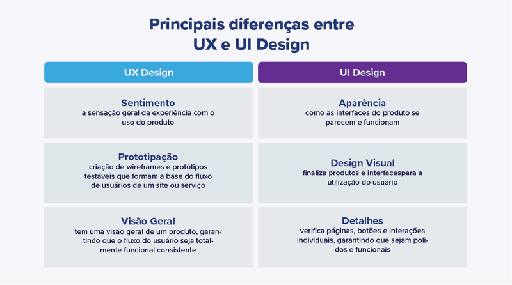

Aqui está uma sugestão de post para o Instagram, curta e envolvente, baseada na imagem:

---

**Capa da imagem:** A própria imagem fornecida.

**Texto da Postagem:**

UX e UI Design: você sabe a diferença? 🤔

Muitas vezes, esses termos são usados de forma intercambiável, mas eles têm focos bem distintos e complementares no mundo do design!

➡️ **UX Design (User Experience):** É sobre a *sensação* e a *experiência* geral do usuário. Pense em como o produto funciona, se é fácil de usar, se a navegação é intuitiva e se o usuário atinge seus objetivos sem frustração. É a arquitetura por trás da casa! 🏡

➡️ **UI Design (User Interface):** Foca na *aparência* visual e na *interação*. É sobre como o produto se parece – as cores, fontes, ícones, botões e todos os elementos visuais que o usuário vê e com os quais interage. É a decoração e o acabamento da casa! ✨

Ambos são cruciais para um produto digital de sucesso! Um não existe sem o outro para entregar uma experiência completa e agradável.

💡 Veja no nosso gráfico as principais diferenças detalhadas. Qual delas te surpreendeu mais? Deixe seu comentário! 👇

#UXDesign #UIDesign #DesignDigital #ExperienciaDoUsuario #InterfaceDoUsuario #ProductDesign #DesignThinking #Tech #DesenvolvimentoDeProduto

In [ ]:
from IPython.display import display, Markdown
image = Image.open(img_path)
image.thumbnail([512,512])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Escreva uma postagem de instagram curta e envolvente baseada nesta imagem."
    ]
)

display(image)
Markdown(response.text)

## Upload Arquivos

Agora que você viu como enviar prompts multimodais, tente enviar arquivos de diferentes tipos de multimídia para a API. Para imagens pequenas, como o exemplo multimodal anterior, você pode apontar o modelo Gemini diretamente para um arquivo local ao fornecer um prompt. Quando você tem arquivos maiores, muitos arquivos ou arquivos que não deseja enviar repetidamente, pode usar a API de Upload de Arquivos e, em seguida, passar o arquivo por referência.

Para arquivos de texto, imagens, vídeos e áudio maiores, envie os arquivos com a API de Arquivos antes de incluí-los nos prompts.

### Carregar arquivo de texto

Vamos começar enviando um arquivo de texto. Neste caso, você usará uma transcrição de 400 páginas de [Apollo 11](https://www.nasa.gov/history/alsj/a11/a11trans.html).

In [ ]:
# Prepare the file to be uploaded
TEXT = "https://storage.googleapis.com/generativeai-downloads/data/a11.txt"  # @param {type: "string"}
text_bytes = requests.get(TEXT).content

text_path = pathlib.Path('a11.txt')
text_path.write_bytes(text_bytes)

847790

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=text_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Você pode me dar um resumo dessas informações, por favor?",
    ]
)

Markdown(response.text)

Este é um resumo da transcrição de áudio da missão Apollo 11, do lançamento ao pouso. A comunicação principal é entre a tripulação (CDR - Comandante Neil Armstrong, CMP - Piloto do Módulo de Comando Michael Collins, LMP - Piloto do Módulo Lunar Edwin "Buzz" Aldrin) e o Controle da Missão (CC - Capcom).

**1. Lançamento e Injeção Trans-Lunar (TLI):**
*   O lançamento ocorre sem problemas, com "GOs" sucessivos do Controle da Missão para as etapas de propulsão.
*   A tripulação relata uma "viagem magnífica" a bordo do Saturn V.
*   A Injeção Trans-Lunar (TLI) é bem-sucedida, colocando a nave em rota para a Lua.
*   Collins é o primeiro a relatar os parâmetros orbitais.

**2. Transposição e Acoplagem:**
*   A acoplagem entre o Módulo de Comando (Columbia) e o Módulo Lunar (Eagle) é realizada com sucesso, embora Collins relate ter usado mais combustível do que o esperado e tido algumas "piruetas".
*   São observadas anomalias menores no sistema de controle de reação (RCS), como o aquecedor do quad Bravo.

**3. Módulo Lunar (LM) Ingressão e Despejo do S-IVB:**
*   A tripulação entra no LM para verificações iniciais. São observadas pequenas questões de pressurização da cabine e na extensão da sonda de acoplagem.
*   O estágio superior do Saturn V (S-IVB) é intencionalmente ventilado e jogado fora para uma trajetória de "estilingue" em torno da Lua, para cair no espaço profundo. A tripulação tenta observar o evento, mas a visão é limitada.
*   São realizadas transmissões de TV para o público, mostrando a Terra e o interior da espaçonave.

**4. Fase de Cruzeiro Trans-Lunar:**
*   A tripulação realiza verificações de alinhamento óptico (P23), enfrentando desafios com a linha de retículo do sextante e leituras de Delta-R.
*   Discussões sobre o uso de combustível e a decisão de pular uma das correções de curso planejadas (MCC1).
*   A tripulação tem períodos de descanso.

**5. Inserção na Órbita Lunar (LOI-1 e LOI-2):**
*   A queima de LOI-1 é bem-sucedida, inserindo a Apollo 11 em órbita lunar. A tripulação descreve uma "vista espetacular" da Lua.
*   Queima de LOI-2 para refinar a órbita, também bem-sucedida.

**6. Ativação do Módulo Lunar e Desacoplagem:**
*   O LM (Eagle) é totalmente ativado e verificado em órbita lunar.
*   São realizadas mais transmissões de TV, desta vez mostrando o interior do LM em detalhes. Buzz Aldrin demonstra exercícios em gravidade zero e a placa do LM.
*   O LM é desacoplado do Módulo de Comando (Columbia). A tripulação relata que "a Águia tem asas".

**7. Início da Descida (DOI) e Pouso (PDI):**
*   A queima de Inserção na Órbita de Descida (DOI) é bem-sucedida.
*   A queima de Início de Descida Motorizada (PDI) começa. A tripulação observa pontos de referência lunar.
*   Alarmes do programa (1201, 1202) são relatados no LM, mas o Controle da Missão os aprova para continuar.
*   Neil Armstrong assume o controle manual para desviar de um campo de rochas e um grande impacto de cratera.
*   **"CONTATO LUZ."** (Os sensores das pernas de pouso tocam a superfície).
*   **"MOTOR DESLIGADO."**
*   **"Houston, aqui é a Base da Tranquilidade. A ÁGUIA POUSOU."** (Anúncio icônico de Neil Armstrong).
*   Aldrin descreve o toque "muito suave" e as primeiras observações da superfície: fina, pulverulenta, coesa.
*   A tripulação relata sua rápida adaptação à gravidade de 1/6 G.

**8. Atividade Extraveicular (EVA - Caminhada Lunar):**
*   O painel de experimentos de vento solar é implantado, seguido pela bandeira dos EUA.
*   O Presidente Nixon faz uma ligação telefônica histórica para a superfície lunar.
*   Aldrin demonstra a locomoção na superfície, descrevendo-a como "desolação magnífica".
*   São coletadas amostras de rochas e tubos de perfuração.
*   O Experiment Seismic Passivo (PSE) e o Refletor de Laser (LR3) são implantados.
*   A tripulação descreve a geologia da superfície e observa anomalias menores, como um medidor de nível convex em um dos experimentos.
*   A EVA é concluída, com a tripulação retornando ao LM.

**9. Pós-EVA e Ascensão:**
*   A tripulação relata o sucesso da EVA e as primeiras observações geológicas.
*   O LM é despressurizado para remover equipamentos como as mochilas PLSS (jogado na superfície, os choques registrados pelo sismômetro).
*   O motor de ascensão é testado e dispara com sucesso.
*   A Águia decola da superfície lunar: "A Águia está de volta em órbita".
*   Os parâmetros orbitais da Eagle são confirmados.

**10. Encontro e Acoplagem em Órbita Lunar:**
*   O Módulo de Comando (Columbia) realiza manobras para se encontrar com o LM.
*   Acoplagem bem-sucedida.

**11. Descarte do LM e Injeção Trans-Terra (TEI):**
*   A tripulação se transfere de volta para o Columbia e joga o LM, que intencionalmente impacta a superfície lunar (choque novamente detectado pelo PSE).
*   A queima de Injeção Trans-Terra (TEI) é realizada, enviando a espaçonave para casa: "Hora de abrir as portas do LRL [Laboratório de Recebimento Lunar], Charlie." Neil Armstrong: "Foi uma queima linda. Não há melhor."

**12. Costa Trans-Terra e Reentrada:**
*   A tripulação faz mais transmissões de TV, mostrando a Lua encolhendo e a Terra crescendo.
*   São realizadas demonstrações de comida em gravidade zero e truques de física.
*   A tripulação se prepara para a reentrada.
*   São discutidas as condições meteorológicas de recuperação, que parecem favoráveis.
*   O Módulo de Serviço é descartado.
*   As comunicações se tornam intermitentes à medida que a cápsula reentra na atmosfera.
*   As chamadas de rádio para a tripulação persistem através do blecaute de reentrada.
*   **"DRÓGUES!"** (Implantação de paraquedas de freio).
*   **"HORNET."** (Contato com o navio de recuperação).
*   **"SPLASHDOWN!"** (Impacto na água).
*   A tripulação e a posição de pouso são confirmados pelo Hornet.

A transcrição detalha não apenas os procedimentos da missão, mas também as observações pessoais da tripulação, suas piadas internas, discussões técnicas com o controle da missão e a emoção do momento histórico do pouso lunar e do retorno à Terra.

### Carregar um arquivo PDF

Esta página em PDF é um artigo intitulado [Edição suave de propriedades de materiais de objetos](https://research.google/blog/smoothly-editing-material-properties-of-objects-with-text-to-image-models-and-synthetic-data/) com modelos de texto para imagem e dados sintéticos disponíveis no Google Research Blog.

Primeiro você baixará um arquivo PDF de um URL e o salvará localmente como "article.pdf

In [ ]:
# Prepare the file to be uploaded
PDF = "https://storage.googleapis.com/generativeai-downloads/data/Smoothly%20editing%20material%20properties%20of%20objects%20with%20text-to-image%20models%20and%20synthetic%20data.pdf"  # @param {type: "string"}
pdf_bytes = requests.get(PDF).content

pdf_path = pathlib.Path('article.pdf')
pdf_path.write_bytes(pdf_bytes)

6695391

Em segundo lugar, você carregará o arquivo PDF salvo e gerará um resumo com marcadores do seu conteúdo.

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Você pode resumir este arquivo em uma lista com marcadores?",
    ]
)

Markdown(response.text)

Aqui está um resumo do arquivo em uma lista com marcadores:

*   **Problema:** Edição de propriedades de materiais em fotos (cor, brilho, transparência) é difícil de fazer de forma fotorealística e com controle preciso usando ferramentas existentes. Abordagens anteriores como decomposição de imagem intrínseca sofrem de ambiguidade, e modelos de texto para imagem (T2I) lutam para dissociar material e forma.
*   **Solução Proposta:** Um método que aprimora um modelo de geração de imagem com edição paramétrica de propriedades de materiais.
*   **Metodologia:**
    *   **Dados Sintéticos:** Utiliza gráficos 3D tradicionais e renderização baseada em física para criar um grande dataset sintético de 100 modelos 3D de objetos domésticos. Para cada objeto, são geradas "imagens base" variando o material, ângulo da câmera e iluminação.
    *   **Edição Paramétrica:** Para cada imagem base, um único atributo do material (ex: rugosidade, transparência) é alterado para produzir múltiplas versões de imagem com diferentes "forças de edição" (um valor escalar de -1 a +1), mantendo a forma do objeto, iluminação e ângulo da câmera.
    *   **Fine-tuning do Modelo:** A arquitetura do Stable Diffusion 1.5 (um modelo latente de difusão para geração T2I) é modificada para aceitar o valor da força de edição. O modelo é então ajustado (fine-tuned) no dataset sintético, aprendendo a editar apenas a propriedade do material desejada com base na imagem de contexto, instrução e força de edição.
    *   **Generalização:** O modelo, treinado com dados sintéticos relativamente pequenos, generaliza para imagens do mundo real, permitindo a edição de materiais mantendo os outros atributos (forma, iluminação) intactos.
*   **Resultados e Exemplos:**
    *   O método funciona bem, mudando a aparência do objeto (ex: metálico, transparente) enquanto retém a forma e a iluminação da imagem.
    *   Exemplos incluem alterar a rugosidade de um bule, a transparência de uma estátua de cupido, o metálico de um vaso e o albedo de uma estátua de Buda.
    *   Demonstra efeitos de iluminação cáusticos realistas e preenchimento de estruturas internas invisíveis em objetos transparentes.
    *   **Estudo de Usuário:** Comparado a um método baseline (InstructPix2Pix), o método proposto foi considerado mais fotorealístico (69,6% vs. 30,4%) e fortemente preferido (70,2% vs. 29,8%).
*   **Aplicações:**
    *   Visualizar como a repintura de um cômodo pode parecer.
    *   Mock-ups de novos designs de produtos para arquitetos, artistas e designers.
    *   **Consistência 3D:** As edições são visualmente consistentes e podem ser usadas em tarefas 3D downstream, como reconstrução NeRF, permitindo sintetizar novas vistas de uma cena com as propriedades de material editadas.
*   **Conclusão:** A técnica aproveita modelos T2I pré-treinados e dados sintéticos para permitir a edição fotorealística e controlável de propriedades de materiais em imagens. Embora o modelo possa ter dificuldades com detalhes ocultos, o potencial para edições de materiais controláveis é promissor.
*   **Agradecimentos:** O trabalho foi possível graças ao autor principal Prafull Sharma e coautores, e agora faz parte do Google DeepMind.

### Carregar um arquivo de áudio

Neste caso, você usará uma [gravação de som](https://www.jfklibrary.org/asset-viewer/archives/jfkwha-006) do discurso do Estado da União do presidente John F. Kennedy em 1961.

In [ ]:
# Prepare the file to be uploaded
AUDIO = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Address_30_January_1961.mp3"  # @param {type: "string"}
audio_bytes = requests.get(AUDIO).content

audio_path = pathlib.Path('audio.mp3')
audio_path.write_bytes(audio_bytes)

41762063

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=audio_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Ouça atentamente o seguinte arquivo de áudio. Forneça um breve resumo",
    ]
)

Markdown(response.text)

No seu primeiro Discurso do Estado da União em 30 de janeiro de 1961, o Presidente John F. Kennedy abordou uma série de desafios internos e externos que os Estados Unidos enfrentavam.

**Principais pontos:**

1.  **Economia Doméstica:** Descreveu uma economia em dificuldades, com recessão, alto desemprego, crescimento diminuído e rendimentos agrícolas em queda. Propôs medidas como o aumento da compensação por desemprego, assistência alimentar, reabilitação de áreas deprimidas, aumento do salário mínimo e incentivos fiscais para o investimento.
2.  **Balança de Pagamentos:** Reconheceu um défice significativo na balança de pagamentos e a saída de ouro. Garantiu a solidez do dólar e prometeu que não haveria desvalorização ou restrições comerciais, mas apelou aos aliados para partilharem mais dos encargos financeiros.
3.  **Questões Sociais e Educacionais:** Sublinhou a necessidade urgente de melhorias na habitação, educação (salas de aula superlotadas, falta de professores qualificados), saúde e justiça social, defendendo novos programas e financiamento federal.
4.  **Cenário Global:** Descreveu uma "maré desfavorável" e uma "hora de perigo máximo" a nível internacional, com pressões comunistas na Ásia (Laos), instabilidade na África (Congo) e a presença comunista em Cuba. Afirmou que a dominação comunista não seria negociável no hemisfério ocidental e destacou o enfraquecimento das alianças da NATO.
5.  **Estratégia e Ferramentas:** Apresentou uma estratégia abrangente, referindo que o país deve dar "igual atenção" tanto ao "ramo de oliveira" (diplomacia e cooperação) quanto às "flechas" (poderio militar).
    *   **Militar:** Anunciou uma reavaliação da estratégia de defesa, incluindo o reforço da capacidade de transporte aéreo, a aceleração do programa de submarinos Polaris e a racionalização do programa de mísseis para garantir a dissuasão.
    *   **Económica e Diplomática:** Propôs novos programas de ajuda externa (como a Aliança para o Progresso na América Latina), iniciativas "Alimentos para a Paz" e a criação de um Corpo de Paz (Peace Corps) para mobilizar o talento americano no estrangeiro.
    *   **Cooperação Internacional:** Apelou a uma maior cooperação com a União Soviética e outras nações em áreas como a previsão meteorológica e os programas espaciais, e reforçou o apoio às Nações Unidas como um instrumento crucial para a paz.
6.  **Apelo à Ação:** Concluiu com um apelo sóbrio à dedicação e ao trabalho árduo dos americanos, reconhecendo que "a maré é desfavorável" e que "as notícias serão piores antes de serem melhores", mas expressando confiança na capacidade do país para enfrentar os desafios.

### Processar um link do YouTube

Para links do YouTube, você não precisa enviar explicitamente o conteúdo do arquivo de vídeo, mas precisa declarar explicitamente o URL do vídeo que deseja que o modelo processe como parte do `contents` da solicitação. Para mais informações, consulte a documentação do [vision](https://ai.google.dev/gemini-api/docs/vision?lang=python#youtube), incluindo os recursos e limites.

> **Observação:** você só pode enviar até um link do YouTube por solicitação de `generate_content`.

> **Observação:** Se o texto inserido incluir links do YouTube, o sistema não os processará, o que pode resultar em respostas incorretas. Para garantir o processamento correto, forneça explicitamente a URL usando o parâmetro `file_uri` em `FileData`.

O exemplo a seguir mostra como você pode usar o modelo para resumir o vídeo. Neste caso, usa um vídeo de um trecho do filme [Mãos Talentosas]("https://www.youtube.com/watch?v=NvQWY_odQrs").

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents= types.Content(
        parts=[
            types.Part(text="Resuma este vídeo."),
            types.Part(
                file_data=types.FileData(file_uri='https://www.youtube.com/watch?v=NvQWY_odQrs')
            )
        ]
    )
)

Markdown(response.text)

El video narra la inspiradora historia de Ben Carson, desde su difícil infancia hasta convertirse en un renombrado neurocirujano.

De niño, Ben era un estudiante con bajo rendimiento, obteniendo malas calificaciones y siendo objeto de burlas. Su madre, a pesar de sus propias limitaciones (más tarde se revela que es analfabeta), tenía una fe inquebrantable en su potencial. Ella lo desafió, diciéndole que era inteligente y que tenía "un mundo entero" dentro de su cabeza, instándolo a usar su imaginación. Para fomentar sus estudios, prohibió la televisión y les exigió a él y a su hermano que leyeran libros y presentaran resúmenes.

Motivado por el apoyo de su madre y la inspiración de un sermón sobre un médico misionero, Ben se dedicó a sus estudios, mejorando drásticamente sus calificaciones. De adulto, Ben Carson buscó una residencia en neurocirugía en el prestigioso Hospital Johns Hopkins. A pesar de la intensa competencia y las dudas iniciales, Ben articuló su creencia en los "milagros" y en el poder del intelecto humano para lograr cosas extraordinarias.

A lo largo de su carrera, Ben Carson se enfrentó a decisiones médicas arriesgadas. Realizó con éxito una cirugía crucial sin supervisión, arriesgando su carrera, y trató eficazmente a una joven paciente con un diagnóstico desfavorable, demostrando su capacidad para ir más allá de lo establecido. El punto culminante de su carrera llegó al enfrentar el desafío de separar gemelos craneópagos (unidos por la cabeza), un procedimiento sin precedentes donde usualmente uno de los bebés moría. Después de una experiencia desalentadora con otra operación de gemelos que no tuvieron éxito, la inquebrantable fe y el estímulo de su madre le recordaron su potencial y la importancia de intentarlo, incluso ante la posibilidad de fracaso.

Impulsado por esta convicción, Ben Carson realizó con éxito la innovadora cirugía de separación de los gemelos Rausch, quienes sobrevivieron y prosperaron. Desde entonces, Ben Carson ha operado a un total de cinco pares de gemelos craneópagos y a cientos de niños, y la hemisferectomía (un procedimiento que él popularizó) se ha convertido en un tratamiento aceptado para convulsiones severas, consolidando su legado como un pionero en la neurocirugía pediátrica.

### Usar contexto de URL

A ferramenta Contexto de URL permite que os modelos Gemini acessem, processem e compreendam diretamente o conteúdo de URLs de páginas da web fornecidas pelo usuário. Isso é fundamental para viabilizar fluxos de trabalho dinâmicos e agênticos, permitindo que os modelos pesquisem, analisem artigos e sintetizem informações da web de forma independente como parte de seu processo de raciocínio.

Neste exemplo, vamos usar dois links como referência e pedirá ao Gemini para encontrar diferenças entre as receitas culinárias presentes em cada um dos links:

In [ ]:
prompt = """
Compare receitas de https://www.tudogostoso.com.br/receita/104383-torta-de-limao.html
e de https://www.tudogostoso.com.br/receita/121412-torta-de-maca.html,
liste as principais diferenças entre eles.
"""

tools = []
tools.append(types.Tool(url_context=types.UrlContext))

client = genai.Client(api_key=GOOGLE_API_KEY)
config = types.GenerateContentConfig(
    tools=tools,
)

response = client.models.generate_content(
      contents=[prompt],
      model=MODEL_ID,
      config=config
)

Markdown(response.text)

As principais diferenças entre a Torta de Limão e a Torta de Maçã, de acordo com as receitas do TudoGostoso, são as seguintes:

**1. Ingredientes Principais:**
*   **Torta de Limão:** Utiliza limão como o ingrediente principal para o recheio, que é feito com leite condensado, creme de leite e suco de limão. A cobertura é um merengue feito com claras em neve e açúcar.
*   **Torta de Maçã:** O recheio é baseado em maçãs raladas cozidas com açúcar, canela e suco de limão. O "creminho" é feito com leite condensado, creme de leite, gemas e baunilha. Não possui uma cobertura de merengue, mas sim polvilhada com canela.

**2. Composição da Massa:**
*   Ambas as receitas usam biscoito maisena triturado com margarina para a base da massa.
*   A Torta de Limão leva a massa ao forno pré-aquecido por aproximadamente 10 minutos.
*   A Torta de Maçã não especifica assar a base de biscoitos antes de adicionar os recheios, apenas que a torta completa é assada no final.

**3. Recheio e Cobertura/Finalização:**
*   **Torta de Limão:** O recheio é um creme cítrico e o destaque é o merengue tostado por cima.
*   **Torta de Maçã:** Possui duas camadas de recheio: uma de doce de maçã e outra de um creme à base de gemas e leite condensado. É finalizada com canela em pó.

**4. Tempo de Preparo e Dificuldade:**
*   **Torta de Limão:** Tempo total de preparo de 25 minutos, classificada como "Fácil".
*   **Torta de Maçã:** Tempo total de preparo de 40 minutos. A dificuldade não é explicitamente mencionada como "fácil" na descrição principal, mas as etapas são relativamente simples.

**5. Número de Porções:**
*   **Torta de Limão:** Rende 15 porções.
*   **Torta de Maçã:** Rende 10 porções.

Em resumo, enquanto ambas são tortas doces com base de biscoito, a Torta de Limão foca no frescor cítrico e uma cobertura de merengue, a Torta de Maçã apresenta um recheio de fruta cozida com especiarias e um creme complementar, assada com os recheios.